In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import ast
#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

# 1. 데이터 불러오기
df = pd.read_csv('../../../data/preprocess(1).csv')


라이브러리 로드 완료


In [93]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# 긍정 비율
df["positive_ratio"] = df["positive"] / (df["positive"] + df["negative"])

# 부정 비율
df["negative_ratio"] = df["negative"] / (df["positive"] + df["negative"])

# 가격 변환
df["price_usd"] = df["price"] / 100

# 메인 장르 추출
EXCLUDE_GENRES = ["Indie","Massively Multiplayer", "Audio Production","Software Training","Photo Editing", "Utilities","Education" ,"Design & Illustration","Game Development","Video Production"]

def get_main_genre(x):
    try:
        genre_list = ast.literal_eval(x)
        
        # 제외 장르 제거
        filtered = [g for g in genre_list if g not in EXCLUDE_GENRES]
        
        return filtered[0] if len(filtered) > 0 else np.nan
        
    except:
        return np.nan

df["main_genre"] = df["genres"].apply(get_main_genre)

df["main_genre"] = df["genres"].apply(get_main_genre)

# 출시일 변환
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# 확인
print(df.shape)
print(df[["name", "main_genre", "positive_ratio", "total_reviews", "price_usd", "ccu", "is_early_access"]].head())

(9692, 20)
                             name main_genre  positive_ratio  total_reviews  \
0                      Last Epoch     Action        0.795739         110623   
1                   7 Days to Die     Action        0.886076         370046   
2                       CyberCorp     Action        0.826087            322   
3              Sons Of The Forest     Action        0.877533         253546   
4  Warhammer 40,000: Rogue Trader     Action        0.855705          30805   

   price_usd    ccu  is_early_access  
0      34.99   5831            False  
1      44.99  17045            False  
2      14.99      3            False  
3      29.99   4450            False  
4      49.99   3582            False  


In [94]:
# 리뷰 규모 기준 stratum 생성
df["stratum"] = pd.cut(
    df["total_reviews"],
    bins=[0, 100, 500, 1000, 5000, np.inf],
    labels=["very_small", "small", "mid", "large", "very_large"]
)


In [95]:
# 확인
print(df[[
    "name", 
    "positive", 
    "negative", 
    "positive_ratio", 
    "total_reviews", 
    "price_usd", 
    "main_genre", 
    "stratum"
]].head())

                             name  positive  negative  positive_ratio  \
0                      Last Epoch     88027     22596        0.795739   
1                   7 Days to Die    327889     42157        0.886076   
2                       CyberCorp       266        56        0.826087   
3              Sons Of The Forest    222495     31051        0.877533   
4  Warhammer 40,000: Rogue Trader     26360      4445        0.855705   

   total_reviews  price_usd main_genre     stratum  
0         110623      34.99     Action  very_large  
1         370046      44.99     Action  very_large  
2            322      14.99     Action       small  
3         253546      29.99     Action  very_large  
4          30805      49.99     Action  very_large  


In [96]:
from scipy.stats import kruskal

def kruskal_test(col):
    groups = [
        g[col].dropna().values
        for _, g in df.groupby("stratum")
    ]
    
    result = kruskal(*groups)
    print(f"{col} p-value:", result.pvalue)

kruskal_test("positive_ratio")
kruskal_test("price_usd")
kruskal_test("ccu")
kruskal_test("owners_lower")

positive_ratio p-value: 1.0675328504111662e-19
price_usd p-value: 7.702127561601642e-222
ccu p-value: 0.0
owners_lower p-value: 0.0


장르별 요약 분석

In [97]:
genre_summary = (
    df.groupby("main_genre")
    .agg(
        game_count=("appid", "count"),
        avg_positive_ratio=("positive_ratio", "mean"),
        median_positive_ratio=("positive_ratio", "median"),
        avg_total_reviews=("total_reviews", "mean"),
        median_total_reviews=("total_reviews", "median"),
        avg_price=("price_usd", "mean"),
        median_price=("price_usd", "median"),
        avg_ccu=("ccu", "mean"),
        median_ccu=("ccu", "median"),
        early_access_rate=("is_early_access", "mean"),
        f2p_rate=("is_f2p", "mean")
    )
    .sort_values("median_total_reviews", ascending=False)
)

genre_summary

,game_count,avg_positive_ratio,median_positive_ratio,avg_total_reviews,median_total_reviews,avg_price,median_price,avg_ccu,median_ccu,early_access_rate,f2p_rate
main_genre,,,,,,,,,,,
RPG,359,0.830105,0.863014,635.991643,76.0,10.865989,9.99,253.838440,1.0,0.0,0.0
Simulation,388,0.778940,0.807956,510.206186,64.0,11.100515,9.99,19.860825,1.0,0.0,0.0
Adventure,2474,0.850835,0.892326,690.651172,46.0,8.917926,6.99,23.539612,0.0,0.0,0.0
Strategy,211,0.853126,0.882353,295.981043,39.0,10.930237,9.99,40.601896,0.0,0.0,0.0
Action,4093,0.833892,0.875000,1092.317615,38.0,9.465864,6.99,30.457855,0.0,0.0,0.0
Casual,1745,0.859777,0.902778,495.662464,36.0,6.587158,4.99,31.930086,0.0,0.0,0.0
Racing,39,0.823135,0.822011,2505.692308,31.0,7.658462,4.99,28.871795,0.0,0.0,0.0
Sports,5,0.937646,0.968051,126.000000,13.0,3.670000,2.39,0.800000,0.0,0.0,0.0


성공유형 다시 만들기

In [98]:
pop_threshold = df["total_reviews"].median()
sat_threshold = df["positive_ratio"].median()

print("대중성 기준:", pop_threshold)
print("만족도 기준:", sat_threshold)

df["success_type"] = np.select(
    [
        (df["total_reviews"] >= pop_threshold) & (df["positive_ratio"] >= sat_threshold),
        (df["total_reviews"] >= pop_threshold) & (df["positive_ratio"] < sat_threshold),
        (df["total_reviews"] < pop_threshold) & (df["positive_ratio"] >= sat_threshold),
        (df["total_reviews"] < pop_threshold) & (df["positive_ratio"] < sat_threshold),
    ],
    [
        "대중성 높고 만족도 높음",
        "대중성 높지만 만족도 낮음",
        "대중성 낮지만 만족도 높음",
        "대중성 낮고 만족도 낮음",
    ],
    default="미분류"
)

df["success_type"].value_counts()

대중성 기준: 41.0
만족도 기준: 0.8837209302325582


success_type
대중성 높지만 만족도 낮음    2616
대중성 낮지만 만족도 높음    2613
대중성 높고 만족도 높음     2235
대중성 낮고 만족도 낮음     2228
Name: count, dtype: int64

장르 × 성공유형 분석

In [99]:
genre_success = pd.crosstab(
    df["main_genre"],
    df["success_type"]
)

genre_success

success_type,대중성 낮고 만족도 낮음,대중성 낮지만 만족도 높음,대중성 높고 만족도 높음,대중성 높지만 만족도 낮음
main_genre,,,,
Action,979,1129,838,1147
Adventure,527,630,669,648
Casual,402,540,431,372
RPG,60,74,86,139
Racing,16,7,11,5
Simulation,101,56,58,173
Sports,1,2,2,0
Strategy,48,61,44,58


In [100]:
genre_success_ratio = pd.crosstab(
    df["main_genre"],
    df["success_type"],
    normalize="index"
) * 100

genre_success_ratio.round(1)

success_type,대중성 낮고 만족도 낮음,대중성 낮지만 만족도 높음,대중성 높고 만족도 높음,대중성 높지만 만족도 낮음
main_genre,,,,
Action,23.9,27.6,20.5,28.0
Adventure,21.3,25.5,27.0,26.2
Casual,23.0,30.9,24.7,21.3
RPG,16.7,20.6,24.0,38.7
Racing,41.0,17.9,28.2,12.8
Simulation,26.0,14.4,14.9,44.6
Sports,20.0,40.0,40.0,0.0
Strategy,22.7,28.9,20.9,27.5


통계검정: 장르별 차이

In [101]:
from scipy.stats import kruskal

def kruskal_by_genre(col):
    groups = [
        group[col].dropna().values
        for name, group in df.groupby("main_genre")
        if len(group[col].dropna()) >= 3
    ]
    
    result = kruskal(*groups)
    print(f"{col}")
    print("statistic:", result.statistic)
    print("p-value:", result.pvalue)
    
    if result.pvalue < 0.05:
        print("장르별 차이가 통계적으로 유의함")
    else:
        print("장르별 차이가 통계적으로 뚜렷하지 않음")
    print()

In [102]:
kruskal_by_genre("positive_ratio")
kruskal_by_genre("total_reviews")
kruskal_by_genre("price_usd")
kruskal_by_genre("ccu")
kruskal_by_genre("owners_lower")

positive_ratio
statistic: 131.73649492619577
p-value: 2.725462526096159e-25
장르별 차이가 통계적으로 유의함

total_reviews
statistic: 72.70889535819758
p-value: 4.1814979133737474e-13
장르별 차이가 통계적으로 유의함

price_usd
statistic: 297.7489670587631
p-value: 1.829838150657824e-60
장르별 차이가 통계적으로 유의함

ccu
statistic: 120.24087054712855
p-value: 6.825519309163757e-23
장르별 차이가 통계적으로 유의함

owners_lower
statistic: 91.04510408597032
p-value: 7.54689306703035e-17
장르별 차이가 통계적으로 유의함



## 시각화

장르별 긍정비율

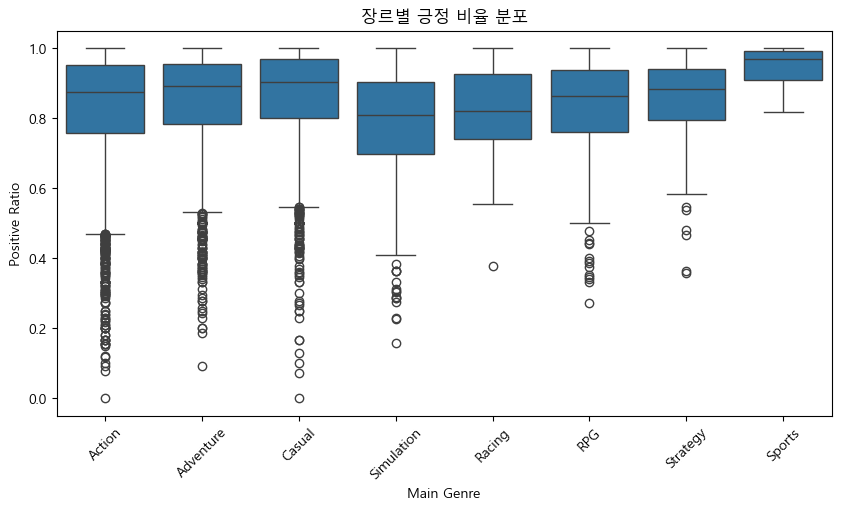

In [103]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="main_genre", y="positive_ratio")
plt.title("장르별 긍정 비율 분포")
plt.xlabel("Main Genre")
plt.ylabel("Positive Ratio")
plt.xticks(rotation=45)
plt.show()

장르별 리뷰수 시각화

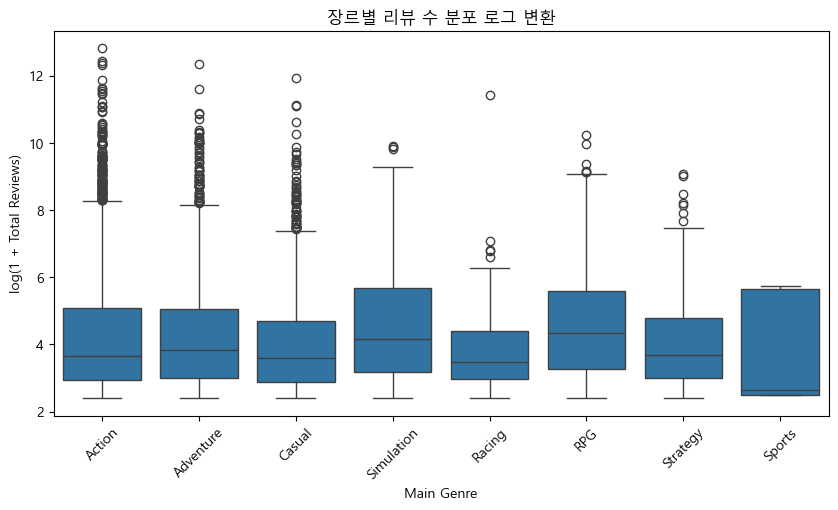

In [104]:
df["log_total_reviews"] = np.log1p(df["total_reviews"])

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="main_genre", y="log_total_reviews")
plt.title("장르별 리뷰 수 분포 로그 변환")
plt.xlabel("Main Genre")
plt.ylabel("log(1 + Total Reviews)")
plt.xticks(rotation=45)
plt.show()

장르별 성공유형 히트맵

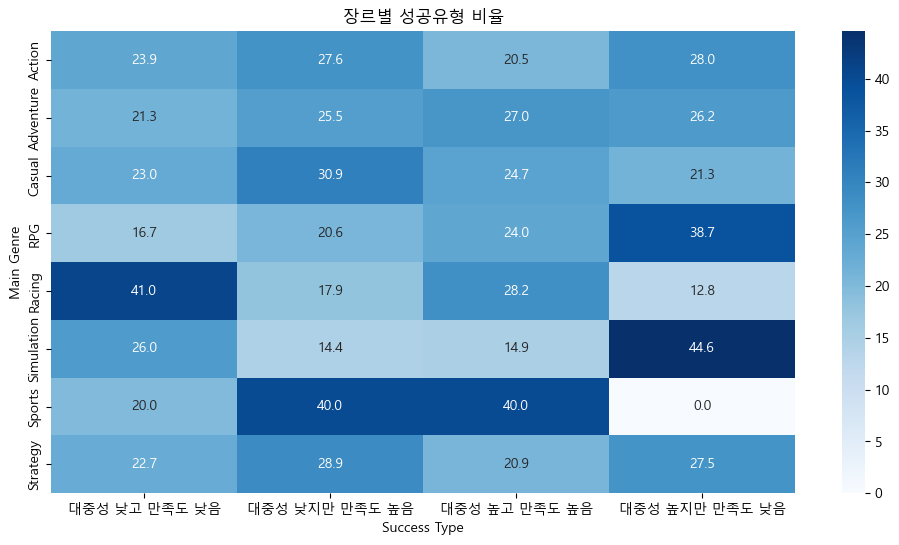

In [105]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    genre_success_ratio,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("장르별 성공유형 비율")
plt.xlabel("Success Type")
plt.ylabel("Main Genre")
plt.show()